In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Crear dataset de clientes bancarios

df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Historial_Pagos": ["Bueno", "Regular", "Malo", "Bueno", "Regular", "Malo", "Bueno", "Regular"],
    "Categoria": ["A", "B", "C", "A", "B", "C", "A", "B"]
})

# Mostrar dataset
print("Dataset original:")
# Mostrar dataset con estilo

df.style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': 'black',
    'border-color': 'gray'
}).set_table_styles([
    {'selector': 'th',
     'props': [('background-color', '#6c63ff'),
               ('color', 'white'),
               ('font-weight', 'bold')]}
])

Dataset original:


,Cliente,Edad,Ingresos,Historial_Pagos,Categoria
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


In [4]:
# Verificar valores nulos

print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Cliente            0
Edad               0
Ingresos           0
Historial_Pagos    0
Categoria          0
dtype: int64


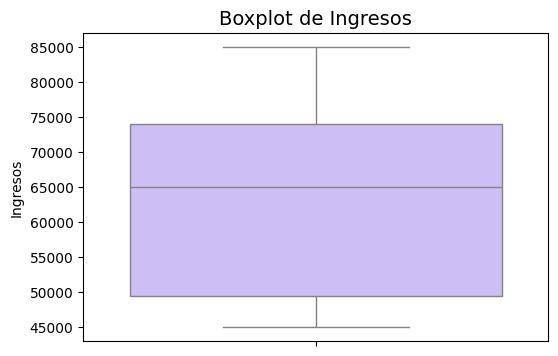

In [5]:
# Crear boxplot para detectar outliers

plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Ingresos"],
    color="#c8b6ff"
)

plt.title("Boxplot de Ingresos", fontsize=14)
plt.ylabel("Ingresos")

plt.show()

In [6]:
# Detectar outliers usando IQR

Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Filtrar datos sin outliers
df_cleaned = df[
    (df["Ingresos"] >= limite_inferior) &
    (df["Ingresos"] <= limite_superior)
]

print("\nCantidad de filas antes:", len(df))
print("Cantidad de filas después:", len(df_cleaned))

Límite inferior: 12750.0
Límite superior: 110750.0

Cantidad de filas antes: 8
Cantidad de filas después: 8


In [7]:
# Normalización Min-Max de ingresos

scaler_minmax = MinMaxScaler()

df_cleaned["Ingresos_Normalizados"] = scaler_minmax.fit_transform(
    df_cleaned[["Ingresos"]]
)

# Estandarización Z-score de edad

scaler_standard = StandardScaler()

df_cleaned["Edad_Estandarizada"] = scaler_standard.fit_transform(
    df_cleaned[["Edad"]]
)

# Mostrar resultados

df_cleaned.style.set_properties(**{
    'background-color': '#f8f9fa',
    'color': 'black',
    'border-color': 'gray'
}).set_table_styles([
    {'selector': 'th',
     'props': [('background-color', '#ff85a2'),
               ('color', 'white'),
               ('font-weight', 'bold')]}
])

,Cliente,Edad,Ingresos,Historial_Pagos,Categoria,Ingresos_Normalizados,Edad_Estandarizada
0,1,25,50000,Bueno,A,0.125000,-1.451747
1,2,40,60000,Regular,B,0.375000,0.441836
2,3,35,70000,Malo,C,0.625000,-0.189358
3,4,50,80000,Bueno,A,0.875000,1.704225
4,5,30,45000,Regular,B,0.000000,-0.820553
5,6,45,85000,Malo,C,1.000000,1.073030
6,7,38,72000,Bueno,A,0.675000,0.189358
7,8,29,48000,Regular,B,0.075000,-0.946792


In [8]:
# One-Hot Encoding para Historial_Pagos

df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=["Historial_Pagos"],
    prefix="Historial"
)

# Label Encoding para Categoria

le = LabelEncoder()

df_cleaned["Categoria_Label"] = le.fit_transform(
    df_cleaned["Categoria"]
)

# Mostrar dataset final

df_cleaned.style.set_properties(**{
    'background-color': '#fff0f5',
    'color': 'black',
    'border-color': 'gray'
}).set_table_styles([
    {'selector': 'th',
     'props': [('background-color', '#ff4d8d'),
               ('color', 'white'),
               ('font-weight', 'bold')]}
])

,Cliente,Edad,Ingresos,Categoria,Ingresos_Normalizados,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoria_Label
0,1,25,50000,A,0.125000,-1.451747,True,False,False,0
1,2,40,60000,B,0.375000,0.441836,False,False,True,1
2,3,35,70000,C,0.625000,-0.189358,False,True,False,2
3,4,50,80000,A,0.875000,1.704225,True,False,False,0
4,5,30,45000,B,0.000000,-0.820553,False,False,True,1
5,6,45,85000,C,1.000000,1.073030,False,True,False,2
6,7,38,72000,A,0.675000,0.189358,True,False,False,0
7,8,29,48000,B,0.075000,-0.946792,False,False,True,1


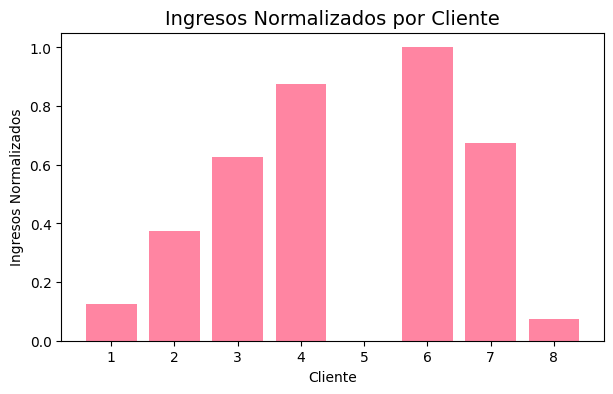

In [9]:
# Gráfico de ingresos normalizados

plt.figure(figsize=(7,4))

plt.bar(
    df_cleaned["Cliente"],
    df_cleaned["Ingresos_Normalizados"],
    color="#ff85a2"
)

plt.title("Ingresos Normalizados por Cliente", fontsize=14)
plt.xlabel("Cliente")
plt.ylabel("Ingresos Normalizados")

plt.show()